In [1]:
# Import evomd and check importation
import evomd
print(evomd.__version__)

0.1.0


In [11]:
# Here you can modify the input file
# constructor, calculator, calculator_check and analyzer
# are still in a different python script. 

input_yaml = """
optimize: maximize          # optimization direction: 'maximize' or 'minimize'
population: 32              # sequences simulated per generation
peptide_len: 20            # length of every peptide
populate_method: [         # generation method (single method; weights ignored)
  swap,
]

extra_mutation: True       # apply an extra random point mutation after swap
also_mutate_probability: 0.1   # probability of that extra mutation per child
parents_ratio: 0.25        # top 25% of the ranking kept as parents each generation

# --- external methods ---
# Names of the Python module(s) (without .py) providing the iteration functions.
# Here a single module (test_hm.py) supplies all three roles.
# constructor: test_hm
calculator:  test_hm
# calculator_check:  test_hm
# analyzer:    test_hm

# --- scales ---
hydrofobic_scale: eisenberg  # options: eisenberg (default), kyte-doolittle, wimley-white, fauchere-pliska.
average_hm: False  # set to True to compute the average of hm and hi

# --- iteration / timing ---
sleep_time: 0              # seconds to wait between simulation-status checks (0 = no wait)
max_check_cycle: 50        # max status-check cycles before unfinished jobs are marked failed
max_generations: 30        # stop after this many generations
target_fitness: null       # stop when best fitness reaches this value (None = no target)

# --- restrictions ---
# Each restriction applies only when its *_restriction flag is True
# (or, for the count-based ones, when the value is non-default).
hydrophobic_restriction: False      # hydrophobic-moment bounds (disabled here)
hydrophobic_min: null               # ignored while hydrophobic_restriction is False
hydrophobic_max: null

hindex_restriction: False        # enforce hydrophobic-index bounds
hindex_min: 0                    # accept sequences with hydrophobic index >= -8
hindex_max: 0                    # no upper bound

charge_restriction: False        # net-charge bounds (disabled here)
charge_min: 0                    # ignored while charge_restriction is False
charge_max: 0

prohibited_patterns: []          # forbidden residue runs (none)
positive_atleast: 0              # minimum positive residues required (0 = no requirement)
negative_atleast: 0              # minimum negative residues required (0 = no requirement)

hdistribution_restriction: False  # enforce a minimum hydrophobicity-distribution score
hdistribution_threshold: 0.9      # minimum accepted distribution score

# --- aa pool ---
mut_aa: ADEFKLNQRSTY  # only these aa are used
"""

In [12]:
# First step is to create an Instructor object
# which reads the yaml instructions

inst = evomd.Instructor(input_yaml)
print(inst)

===== INPUT  CONFIGURATION =====
evomd_directory           : simulation_data
evolver_name              : evolver
optimize                  : maximize
hydrofobic_scale          : eisenberg
average_hm                : False
sequences                 : 0
excluded_sequences        : 0
top_list                  : 10
mut_aa                    : ADEFKLNQRSTY
peptide_len               : 20
population                : 32
populate_method           : 1
method_weights            : 1
extra_mutation            : True
also_mutate_probability   : 0.1
include_parents           : False
avoid_reinsertion         : True
face_slice_angle          : 180.0
pattern                   : None
pattern_options           : None
pattern_weights           : None
pattern_maxmut            : 1
n_flank                   : None
c_flank                   : None
flank_inner               : swap
parents_ratio             : 0.25
populate_weighted         : False
weight_bias               : 0.3
include_discarded         : Fal

In [13]:
# Now you can create an Evolver.
# This is the engine of the evolution.

evo = evomd.Evolver(inst)

# populate the evolver
evo.populate()

# print(evo) is equivalent to evo.show_evolver()
print(evo)

Evolver: Starting sequences
First population.
===== EVOLVER CURRENT STATE =====
Optimization            : maximize
Population method       : ['swap'] + mutation
Started                 : False
Generations             : 0
Current sequences       : 32
Parent sequences        : 0
Discarded sequences     : 0
Total sequences         : 32

Top 10                    Sequence               Gen   Fitness  Hm       Charge  
1                       : RNFRDETENRAKEQTYEKLL   0     -        1.152    0.0     
2                       : LRSANEQSSSNLFNANYRKD   0     -        1.273    1.0     
3                       : YTSNRQNLKEFFNDRYDARR   0     -        3.386    2.0     
4                       : QRQQKLLQFQLFDLKQQSRS   0     -        3.805    3.0     
5                       : TYTFLALKLEDKYYNETDTF   0     -        2.837    -2.0    
6                       : FTLSRKLKARDTSYDQSFDF   0     -        2.387    1.0     
7                       : KQNKAETRREDSDLFKLTAQ   0     -        3.449    1.0     
8       

In [14]:
# Start evolution.
# fast_cycle is used to avoid saving pkl
# file every cycle.

evo.start(fast_cycle=True)

Evolver: Already populated --> skipping


Nothing to create for RNFRDETENRAKEQTYEKLL
Nothing to create for LRSANEQSSSNLFNANYRKD
Nothing to create for YTSNRQNLKEFFNDRYDARR
Nothing to create for QRQQKLLQFQLFDLKQQSRS
Nothing to create for TYTFLALKLEDKYYNETDTF
Nothing to create for FTLSRKLKARDTSYDQSFDF
Nothing to create for KQNKAETRREDSDLFKLTAQ
Nothing to create for KAERNTSNLNKTNRLSAFAL
Nothing to create for QDQAFSDRLSKQRRLAQRKS
Nothing to create for YQLLTFTDTARRYNQEALRY
Nothing to create for NYTEKYTYKEQFYKQAERQS
Nothing to create for SNQLQTYAQKAYNKQEYASN
Nothing to create for ELQDYKQQRAYEKELKKDKT
Nothing to create for SDENDYDREEALTKRTKKDY
Nothing to create for FTKDAYKQRQQEFDYFYLKY
Nothing to create for RTSDNTQAQFYQRSLKSYLK
Nothing to create for AQDTDLELNFDTAALNQEAR
Nothing to create for TAYNNSYDEYSEKLQSNFLS
Nothing to create for LLSDAANELQNDDFDTAKFL
Nothing to create for SKKRKKEATDFNSLQTTTRF
Nothing to create for QKTQLQKERTYAEQAAARAK
Nothing to create for FYLARYAKALSNLKELSRYA
Nothing to create for FNEQEYDANLNSNKQKNFRT
Nothing to 

In [15]:
# Show the results.
# You can also do print(evo)

evo.show_evolver()

===== EVOLVER CURRENT STATE =====
Optimization            : maximize
Population method       : ['swap'] + mutation
Started                 : True
Generations             : 30
Current sequences       : 32
Parent sequences        : 0
Discarded sequences     : 960
Total sequences         : 992

Top 10                    Sequence               Gen   Fitness  Hm       Charge  
1                       : RRFFRRFFRFFRRFLRRARR   27    15.2550  15.255   11.0    
2                       : RRFFRRFLRFFRRFLRRARR   27    15.2480  15.248   11.0    
3                       : RRFFRRFFRLFRRFLRRARR   28    15.2350  15.235   11.0    
4                       : RRFFRRFLRLFRRFLRRARR   29    15.2270  15.227   11.0    
5                       : RRFFRRFYRFFRRFLRRARR   29    15.2100  15.21    11.0    
6                       : RRLFRRFFRFFRRFLRRARR   26    15.2100  15.21    11.0    
7                       : RRLFRRFLRFFRRFLRRARR   27    15.2020  15.202   11.0    
8                       : RRLFRRFFRLFRRFLRRARR   27

-------------
Generations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Population fitness: [2.66853125, 4.5484687500000005, 6.013624999999998, 6.9268125, 7.709656250000001, 8.454125, 9.012375000000002, 9.4810625, 9.967781250000002, 10.420375, 10.92884375, 11.219156250000001, 11.448531249999997, 11.755812500000003, 12.03034375, 12.26765625, 12.48990625, 12.694468749999999, 13.10228125, 13.562656250000002, 13.890937500000001, 14.115093750000005, 14.37915625, 14.674624999999995, 14.868187500000001, 14.890843750000002, 14.930281249999998, 15.004656249999998, 15.067718749999997, 15.117437499999998]
-------------


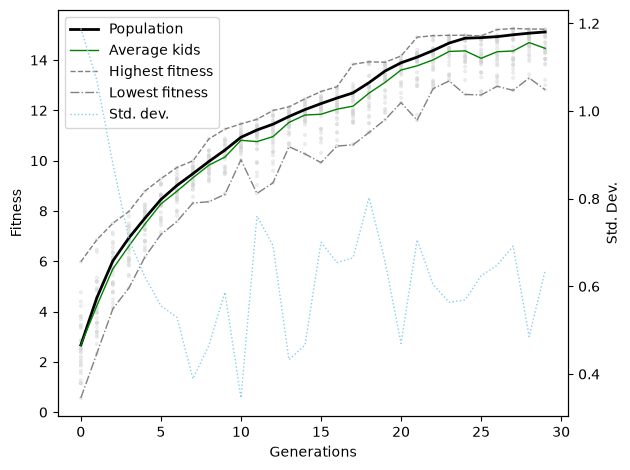

In [16]:
# Plot the evolution.
# show_kids shows the fitness of the sequences
# generated in each generation.
# show_std shows the standard deviation of the 
# generated sequences.
# This plot is automatically saved as evolution.png

evo.plot_evolution(show_kids=True, show_std=True)

In [17]:
# Save the data!

# Save the Evolver object as pkl file
evo.save_pkl()

# Save the sequences in a CSV file.
evo.report_sequences()

print("evolver.pkl saved!")

evolver.pkl saved!


In [18]:
# Analyze the sequences.
# You have to import some complementary functions
# from evomd.viz

from evomd.viz.sequence_logo import plot_sequence_logo
from evomd.viz.peptide_viewer import plot_sequence
print("Complementary methods imported")

Complementary methods imported


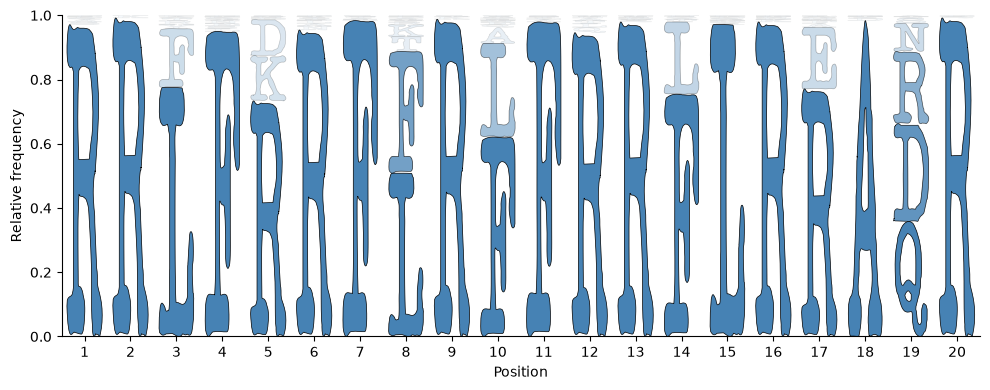

In [19]:
# Plot a sequence logo with any
# list of sequences from Evolver.

# we eant to include only the first
# fourth of the discarded sequences.
fourth = int(len(evo.discarded_sequences) / 4)
sequences = evo.discarded_sequences[:fourth]

# Plot the sequence logo
plot_sequence_logo(sequences=sequences, gradient=True)

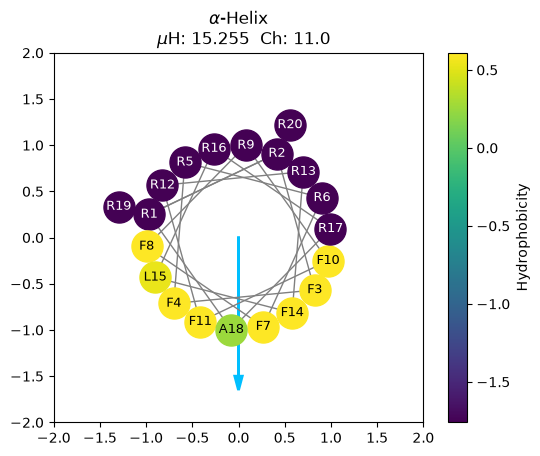

In [20]:
# Are your sequences alpha-helices?
# View it as helix...

# Take the first sequence from discarded_sequences
the_best = evo.discarded_sequences[0]

# plot the helix view
plot_sequence(sequence=the_best, print_hm=True, print_charge=True)